In [17]:
pip install langchain-groq


   ---------------------------------------- 0.0/131.4 kB ? eta -:--:--
   ---------------------------------------- 131.4/131.4 kB 3.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [23]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 509.0 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.1 MB 645.7 kB/s eta 0:00:12
   ----- ---------------------------------- 1.0/8.1 MB 751.1 kB/s eta 0:00:10
   ------ --------------------------------- 1.3/8.1 MB 799.2 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.1 MB 799.2 kB/s eta 0:00:09
   ------- -------------------------------- 1.6/8.1 MB 814.6 kB/s eta 0:00:09
   --------- ------------------------------ 1.8/8.1 MB 83

In [3]:
!pip install langchain

  Using cached langchain-0.3.27-py3-none-any.whl.metadata (7.8 kB)
  Using cached langchain_core-0.3.74-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_text_splitters-0.3.9-py3-none-any.whl.metadata (1.9 kB)
  Using cached langsmith-0.4.13-py3-none-any.whl.metadata (14 kB)
  Using cached pydantic-2.11.7-py3-none-any.whl.metadata (67 kB)
  Using cached orjson-3.11.1-cp312-cp312-win_amd64.whl.metadata (43 kB)
  Using cached zstandard-0.23.0-cp312-cp312-win_amd64.whl.metadata (3.0 kB)
  Using cached pydantic_core-2.33.2-cp312-cp312-win_amd64.whl.metadata (6.9 kB)
  Using cached typing_inspection-0.4.1-py3-none-any.whl.metadata (2.6 kB)
Using cached langchain-0.3.27-py3-none-any.whl (1.0 MB)
Using cached langchain_core-0.3.74-py3-none-any.whl (443 kB)
Using cached langchain_text_splitters-0.3.9-py3-none-any.whl (33 kB)
Using cached langsmith-0.4.13-py3-none-any.whl (372 kB)
Using cached pydantic-2.11.7-py3-none-any.whl (444 kB)
Using cached pydantic_core-2.33.2-cp312-cp312-win_

  You can safely remove it manually.


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()  # Load API key from .env file
api_key = os.getenv("ChatGroq_API_KEY")

In [ ]:
import pandas as pd

def load_transactions(file_path):
    """
    Load CSV or Excel transactions and normalize.
    """
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_excel(file_path)

    # Normalize column names
    df.columns = [col.strip().lower() for col in df.columns]
    df.rename(columns={
        'description': 'desc',
        'amount': 'amount',
        'date': 'date',
        'type': 'type'
    }, inplace=True)

    # Type conversions
    df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    # Drop incomplete rows
    df.dropna(subset=['desc', 'amount', 'date'], inplace=True)
    df.sort_values('date', inplace=True)

    return df

# Test with sample file
df = load_transactions("C:/Users/klevi/Desktop/LANGCHAIN/data/transactions.csv")
df.head()


,date,desc,amount,type
0,2025-07-01,Uber Eats,24.90,Debit
1,2025-07-03,Salary,2000.00,Credit
2,2025-07-05,Aldi,45.70,Debit
3,2025-07-05,Aldi,445.70,Debit
4,2025-07-07,Netflix,15.99,Debit


In [15]:
from langchain.prompts import PromptTemplate
from langchain_groq import ChatGroq
from langchain.chains import LLMChain

llm = ChatGroq(
    temperature=0,
    api_key=api_key,
    model="llama3-70b-8192"#, "llama3-8b-8192"
)

prompt = PromptTemplate(
    input_variables=["description"],
    template="Categorize this transaction: '{description}'. Respond with one word category like Food, Transport, Rent, Shopping, Subscription, Other."
)

categorizer_chain = LLMChain(llm=llm, prompt=prompt)

def categorize_transactions(df):
    df['category'] = df['desc'].apply(lambda x: categorizer_chain.run(description=x))
    return df

df = categorize_transactions(df)
df.head()


C:\Users\klevi\AppData\Local\Temp\ipykernel_18388\3350971239.py:19: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  df['category'] = df['desc'].apply(lambda x: categorizer_chain.run(description=x))


,date,desc,amount,type,category
0,2025-07-01,Uber Eats,24.90,Debit,Food
1,2025-07-03,Salary,2000.00,Credit,Income
2,2025-07-05,Aldi,45.70,Debit,Food
3,2025-07-05,Aldi,445.70,Debit,Food
4,2025-07-07,Netflix,15.99,Debit,Subscription


In [16]:
def detect_suspicious(df):
    suspicious = []

    # Duplicate amounts & dates
    duplicates = df[df.duplicated(['amount', 'date'], keep=False)]
    if not duplicates.empty:
        suspicious.append("Duplicate transactions found.")

    # Calculate mean amount only for Debit transactions
    debit_df = df[df['type'].str.lower() == 'debit']
    mean_debit = debit_df['amount'].mean()

    # Very large debit amounts (> 3 * mean)
    large_spend = debit_df[debit_df['amount'] > mean_debit * 3]
    if not large_spend.empty:
        # Format the suspicious transactions info
        details = large_spend[['date', 'desc', 'amount']].to_dict(orient='records')
        details_str = "\n".join([f"- {d['date']} | {d['desc']} | ${d['amount']}" for d in details])
        suspicious.append(f"Unusually large debit transactions detected:\n{details_str}")

    return suspicious



issues = detect_suspicious(df)
issues


['Unusually large debit transactions detected:\n- 2025-07-05 00:00:00 | Aldi | $445.7']

In [17]:
summary_prompt = PromptTemplate(
    input_variables=["spending_data"],
    template="""
    You are a financial assistant.
    Given this spending summary: {spending_data}
    Write a short report (3-4 sentences) about spending habits and suggest 2 improvements.
    """
)

summary_chain = LLMChain(llm=llm, prompt=summary_prompt)

def summarize_finances(df):
    summary_dict = df.groupby('category')['amount'].sum().to_dict()
    return summary_chain.run(spending_data=str(summary_dict))

ai_summary = summarize_finances(df)
ai_summary


'Based on the provided spending summary, it appears that food expenses account for a significant portion of overall expenditures, totaling $516.30. This suggests that dining out or grocery shopping habits may be an area for improvement. Additionally, the subscription expense of $15.99, although relatively small, could be optimized by reviewing and canceling any unused or unnecessary services. To improve spending habits, I recommend implementing a meal planning and grocery budgeting strategy to reduce food expenses, and conducting a subscription audit to eliminate any unnecessary recurring charges.'

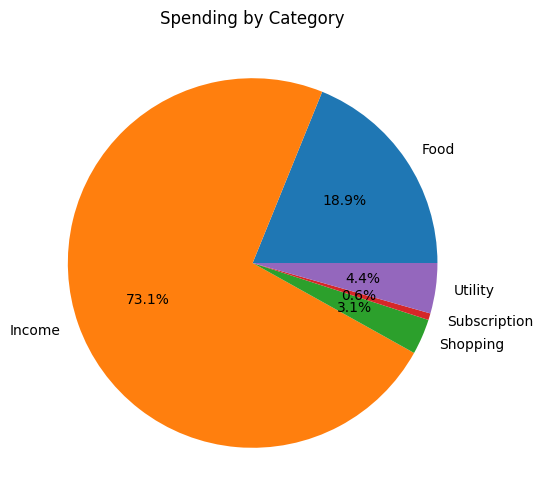

In [24]:
import matplotlib.pyplot as plt

def plot_spending(df):
    category_totals = df.groupby('category')['amount'].sum()
    category_totals.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
    plt.title("Spending by Category")
    plt.ylabel("")
    plt.show()

plot_spending(df)


In [27]:
print("🚨 Issues Found:", issues)
print("\n📊 AI Summary:\n", ai_summary)


🚨 Issues Found: ['Unusually large debit transactions detected:\n- 2025-07-05 00:00:00 | Aldi | $445.7']

📊 AI Summary:
 Based on the provided spending summary, it appears that food expenses account for a significant portion of overall expenditures, totaling $516.30. This suggests that dining out or grocery shopping habits may be an area for improvement. Additionally, the subscription expense of $15.99, although relatively small, could be optimized by reviewing and canceling any unused or unnecessary services. To improve spending habits, I recommend implementing a meal planning and grocery budgeting strategy to reduce food expenses, and conducting a subscription audit to eliminate any unnecessary recurring charges.
